<a href="https://colab.research.google.com/github/janhvi-j712/Full-Stack-Task/blob/master/jovac_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: Import Basic Libraries
import pandas as pd    # used for handling datasets (CSV, Excel, tables, etc.)
import numpy as np     # used for numerical operations and math functions
import matplotlib.pyplot as plt  # used for creating graphs and charts
import seaborn as sns  # used for advanced visualizations
import zipfile         # used for extracting zip files
import os              # used for file handling (like checking folder, listing files)

In [ ]:
# STEP 2: Extract the ZIP file
zip_path = "/content/archive (20).zip"   # path of your uploaded ZIP file
extract_path = "/content/spotify_dataset"  # folder where we will extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)  # extracting all files from zip

print("Extracted Files:", os.listdir(extract_path))  # to see what CSV files are inside

Extracted Files: ['data']


In [ ]:
# STEP 3: Load Main Dataset
data = pd.read_csv(os.path.join(extract_path, "data", "data.csv"))  # loading main dataset
print(data.head())   # showing first 5 rows

   valence  year  acousticness  \
0   0.0594  1921         0.982   
1   0.9630  1921         0.732   
2   0.0394  1921         0.961   
3   0.1650  1921         0.967   
4   0.2530  1921         0.957   

                                             artists  danceability  \
0  ['Sergei Rachmaninoff', 'James Levine', 'Berli...         0.279   
1                                     ['Dennis Day']         0.819   
2  ['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...         0.328   
3                                   ['Frank Parker']         0.275   
4                                     ['Phil Regan']         0.418   

   duration_ms  energy  explicit                      id  instrumentalness  \
0       831667   0.211         0  4BJqT0PrAfrxzMOxytFOIz          0.878000   
1       180533   0.341         0  7xPhfUan2yNtyFG0cUWkt8          0.000000   
2       500062   0.166         0  1o6I8BglA6ylDMrIELygv1          0.913000   
3       210000   0.309         0  3ftBPsC5vPBKxYSee08FDH      

In [ ]:
# STEP 4: Basic Info About Dataset

print(data.shape)   # rows and columns count

(170653, 19)


In [ ]:
print(data.info())  # column names and datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [ ]:
print(data.describe())  # numerical column  summary

             valence           year   acousticness   danceability  \
count  170653.000000  170653.000000  170653.000000  170653.000000   
mean        0.528587    1976.787241       0.502115       0.537396   
std         0.263171      25.917853       0.376032       0.176138   
min         0.000000    1921.000000       0.000000       0.000000   
25%         0.317000    1956.000000       0.102000       0.415000   
50%         0.540000    1977.000000       0.516000       0.548000   
75%         0.747000    1999.000000       0.893000       0.668000   
max         1.000000    2020.000000       0.996000       0.988000   

        duration_ms         energy       explicit  instrumentalness  \
count  1.706530e+05  170653.000000  170653.000000     170653.000000   
mean   2.309483e+05       0.482389       0.084575          0.167010   
std    1.261184e+05       0.267646       0.278249          0.313475   
min    5.108000e+03       0.000000       0.000000          0.000000   
25%    1.698270e+05    

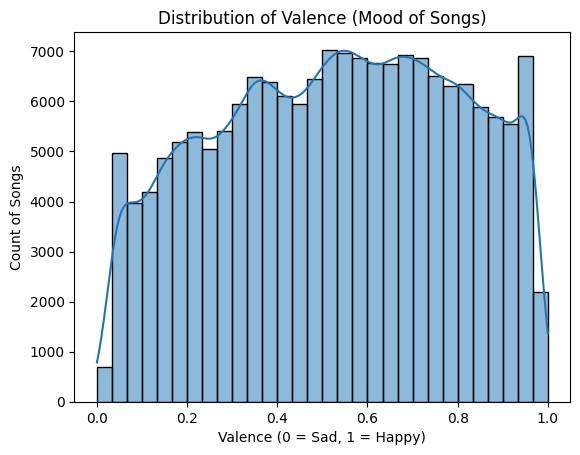

In [ ]:
# STEP 5: Focus on Valence Column
sns.histplot(data['valence'], bins=30, kde=True) #distplot
plt.title("Distribution of Valence (Mood of Songs)")
plt.xlabel("Valence (0 = Sad, 1 = Happy)")
plt.ylabel("Count of Songs")
plt.show()


In [ ]:
# STEP 6: Categorize Songs Based on Valence
def mood_category(val):
    if val < 0.3:
        return "Sad"
    elif val < 0.6:
        return "Neutral"
    else:
        return "Happy"

data['mood'] = data['valence'].apply(mood_category)
print(data[['valence', 'mood']].head())


   valence   mood
0   0.0594    Sad
1   0.9630  Happy
2   0.0394    Sad
3   0.1650    Sad
4   0.2530    Sad


/tmp/ipython-input-353411799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="mood", data=data, palette="viridis")


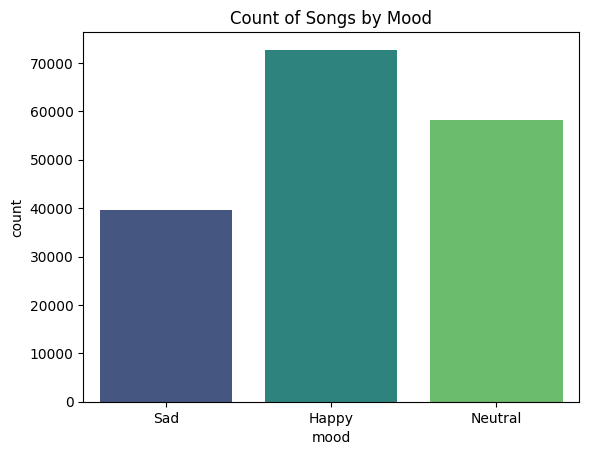

In [ ]:
# STEP 7: Visualization - Count of Each Mood
sns.countplot(x="mood", data=data, palette="viridis")
plt.title("Count of Songs by Mood")
plt.show()


In [ ]:
# STEP 8: Simple Recommendation Function
def recommend_songs(mood, n=5):
    subset = data[data['mood'] == mood]  # filter mood
    return subset[['name', 'artists', 'valence']].sample(n)  # random n songs

#  Recommend 5 happy songs
print(" Recommended Happy Songs:")
print(recommend_songs("Happy", 5))


 Recommended Happy Songs:
                                   name  \
165065                           Родина   
99625                      Spanish Eyes   
93648    Galopa, Galopa - Remasterizado   
77405         Rag Rag Mein Jagi Umangen   
23562   Aaya Toofan Jaag Bharat Ki Nari   

                                      artists  valence  
165065                                ['ДДТ']    0.722  
99625                       ['Elvis Presley']    0.640  
93648   ['Francisco Canaro', 'Carlos Roldán']    0.933  
77405                         ['Renuka Devi']    0.755  
23562                     ['Rafique Gaznavi']    0.831  


In [ ]:
# STEP 9: Recommend Sad Songs
print(" Recommended Sad Songs:")
print(recommend_songs("Sad", 5))   # 5 random sad songs

 Recommended Sad Songs:
                          name                                artists  valence
148295                    Jack                     ['Robin Williams']   0.1040
157949  The Touch Of Your Lips                      ['Sarah Vaughan']   0.1080
105479                Blackout                               ['Muse']   0.0617
19108            Teenage Fever                              ['Drake']   0.1440
147338             Palm Sunday  ['Jerry Garcia Band', 'Jerry Garcia']   0.1650


In [ ]:
# STEP 9: Recommend Emotional Songs
def recommend_emotional_songs(n=5):
    # Filter songs with valence between 0.2 and 0.5 (emotional range)
    results = data[(data['valence'] >= 0.2) & (data['valence'] <= 0.5)]
    if results.empty:
        return "No emotional songs found."
    return results[['name', 'artists', 'valence']].sample(n)



print(recommend_emotional_songs(5))


                                                     name  \
46434                                 Wild Mountain Thyme   
61491   String Quartet No. 4 in C Minor, Op. 18: IV. A...   
2558                                      Love Locked Out   
148872                            My Old Friend The Blues   
89923                        Now You're Gone - Radio Edit   

                                                  artists  valence  
46434                                       ['The Byrds']    0.405  
61491   ['Ludwig van Beethoven', 'Budapest String Quar...    0.425  
2558                                          ['Roy Fox']    0.387  
148872                                    ['Steve Earle']    0.245  
89923                                      ['Basshunter']    0.320  


In [ ]:
# STEP 9: General Mood-Based Recommendation System (with Neutral mood)
def recommend_by_mood(mood, n=5):
    if mood == "happy":
        results = data[data['valence'] > 0.7]
    elif mood == "sad":
        results = data[data['valence'] < 0.3]
    elif mood == "emotional":
        results = data[(data['valence'] >= 0.2) & (data['valence'] <= 0.5)]
    elif mood == "energetic":
        results = data[data['energy'] > 0.7]
    elif mood == "neutral":
        results = data[(data['valence'] >= 0.45) & (data['valence'] <= 0.65)]
    else:
        return "Mood not recognized. Try: happy, sad, emotional, energetic, neutral"

    if results.empty:
        return "No songs found for this mood."
    return results[['name', 'artists', 'valence', 'energy']].sample(n)





In [ ]:
print(recommend_by_mood("happy", 10))     # 10 Happy songs



                                                     name  \
71578                                       Techno Cumbia   
66881                                   It's All Over Now   
33575                                    Medicina de Amor   
50654                                           Hot Stuff   
132852                                  Cash In Your Face   
2951                Preachin' Blues (Up Jumped The Devil)   
83434                                   Hey Joe (Hey Moe)   
11006                              Dreams - 2004 Remaster   
133659      If You Should Lose Me/You'Ll Lose A Goodthing   
24208   Violin Sonata in G Major, K.301/293a: II. Allegro   

                                            artists  valence  energy  
71578                                    ['Selena']    0.956   0.696  
66881                             ['Molly Hatchet']    0.709   0.899  
33575                          ['Raulin Rodriguez']    0.921   0.421  
50654                              ['Donna S

In [ ]:
print(recommend_by_mood("sad", 10))       # 10 Sad songs


                                                     name  \
47625                                      When You're In   
85360                              Looking Down the Cross   
66086                       We All Fall In Love Sometimes   
145530                       When You Say - 2013 Remaster   
78519   Piano Concerto No. 3 in C Minor, Op. 37: II. L...   
67278                                              Memory   
20738                                 Duérmete, Mi Clavel   
138562                        Exhibit A (Transformations)   
135700                       Calme des nuits, Op.68, No.1   
129229                  It Might As Well Be Spring - Edit   

                                                  artists  valence   energy  
47625                                      ['Pink Floyd']   0.1890  0.63200  
85360                                        ['Megadeth']   0.0492  0.98500  
66086                                      ['Elton John']   0.1720  0.15700  
145530          

In [ ]:
print(recommend_by_mood("emotional", 10)) # 10 Emotional songs


                                                  name  \
69452                                              Tha   
152426                                   She's In Love   
61673                                   Alone Together   
8070                                         500 Miles   
147252         El Amor De Mi Vida - Tema Remasterizado   
140632                                        Caroline   
142523               Ae Mere Dil Kahin Aur Chal, Pt. 2   
36609                                 Back To December   
30159                                           Volcán   
58265   Waltzes, Op. 34: No. 1 in A-Flat Major. Vivace   

                                     artists  valence  energy  
69452                         ['Aphex Twin']    0.326  0.4060  
152426                       ['Peter White']    0.346  0.3200  
61673                    ['Dizzy Gillespie']    0.263  0.1740  
8070                ['Peter, Paul and Mary']    0.255  0.0695  
147252                 ['Vicente Fernánde

In [ ]:
print(recommend_by_mood("energetic", 10)) # 10 Energetic songs


                                                     name  \
81129                              You Do Something to Me   
69135             Saturday Night's Alright (For Fighting)   
104932                                     When Thugz Cry   
168187                                              Calor   
120893                                      Drag You Down   
74801   I Am Who They Say I Am (feat. Kevin Gates and ...   
107751                           To Ü (feat. AlunaGeorge)   
55170                                      Beer In Mexico   
59853                               The Dreamer (Reprise)   
73444                                       See You Again   

                                                  artists  valence  energy  
81129                                       ['The Kinks']    0.834   0.907  
69135                                      ['Elton John']    0.961   0.984  
104932                                           ['2Pac']    0.891   0.834  
168187              

In [ ]:
print(recommend_by_mood("neutral", 10))   # 10 Neutral songs

                                                     name  \
36669                                      Christmas Kids   
35707       1970 Somethin' (feat. The Game & Faith Evans)   
119911                                 Boom Biddy Bye Bye   
156385                            Ab Raat Gai Hai Beet Re   
47314                        I Dig Love - Remastered 2014   
165731                                          Chan chan   
53603                           (Ghost) Riders In the Sky   
153375                                      Shukran Allah   
82360                                     Country Comfort   
13858   Something There - From "Beauty and the Beast"/...   

                                                  artists  valence  energy  
36669                                            ['Roar']    0.558   0.754  
35707   ['The Notorious B.I.G.', 'Faith Evans', 'The G...    0.483   0.635  
119911                                   ['Cypress Hill']    0.595   0.614  
156385              